# Introduction to Machine Learning & Data Preprocessing

## 🎯 Learning Objectives
By the end of this lesson, you will understand:
- Core machine learning concepts and applications
- Different types of machine learning
- Basic ML workflow with Scikit-Learn
- Model performance evaluation and confusion matrices
- Data preprocessing techniques
- Real-world ML project implementation

## 📚 Topics Covered
1. **Introduction to Machine Learning**
2. **What is Data Preprocessing?**
3. **Project: Adult Income Classification (Part 1)**

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("📚 All libraries imported successfully!")
print("🔧 Environment configured for machine learning!")

📚 All libraries imported successfully!
🔧 Environment configured for machine learning!


# 🤖 PART 1: Introduction to Machine Learning

## What is Machine Learning?

Machine Learning (ML) is a subset of artificial intelligence that enables computers to learn and make decisions from data without being explicitly programmed for every task.

### Key Concepts:
- **Algorithm**: A set of rules or instructions for solving a problem
- **Model**: A trained algorithm that can make predictions on new data
- **Training**: The process of teaching an algorithm using historical data
- **Prediction**: Using a trained model to make decisions on new, unseen data

### Real-World Applications:
- 🎬 **Netflix**: Movie recommendations based on viewing history
- 🛒 **Amazon**: Product recommendations and fraud detection
- 🚗 **Tesla**: Self-driving cars using computer vision
- 🏥 **Healthcare**: Medical diagnosis and drug discovery
- 📧 **Gmail**: Spam email detection

## Types of Machine Learning

### 1. 🎯 Supervised Learning
- **Definition**: Learning with labeled examples (input-output pairs)
- **Goal**: Predict outcomes for new data
- **Examples**: 
  - Predicting house prices (regression)
  - Email spam detection (classification)
  - Medical diagnosis (classification)

### 2. 🔍 Unsupervised Learning  
- **Definition**: Finding patterns in data without labels
- **Goal**: Discover hidden structure in data
- **Examples**:
  - Customer segmentation (clustering)
  - Market basket analysis (association rules)
  - Dimensionality reduction (PCA)

### 3. 🎮 Reinforcement Learning
- **Definition**: Learning through trial and error with rewards/penalties
- **Goal**: Learn optimal actions in an environment
- **Examples**:
  - Game playing (Chess, Go)
  - Robot navigation
  - Trading algorithms

### Focus of This Course: **Supervised Learning** 🎯

## Basic ML Workflow with Scikit-Learn

The typical machine learning workflow consists of these steps:

### 1. 📊 **Data Collection & Loading**
   - Gather relevant data for your problem
   - Load data into pandas DataFrame

### 2. 🔍 **Exploratory Data Analysis (EDA)**
   - Understand data structure and patterns
   - Identify missing values, outliers, distributions

### 3. 🛠️ **Data Preprocessing**
   - Clean and prepare data for modeling
   - Handle missing values, scale features, encode categories

### 4. 🎯 **Model Selection & Training**
   - Choose appropriate algorithm
   - Split data into train/test sets
   - Train model on training data

### 5. 📈 **Model Evaluation**
   - Test model performance on unseen data
   - Use metrics like accuracy, precision, recall

### 6. 🚀 **Model Deployment**
   - Put model into production
   - Monitor and maintain performance

In [ ]:
# Simple Example: Basic ML Workflow
print("🔧 BASIC ML WORKFLOW EXAMPLE")
print("=" * 50)

# Step 1: Create sample data
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=10000000, n_features=4, n_classes=2, random_state=42)

print(f"📊 Dataset created: {X.shape[0]} samples, {X.shape[1]} features")
print(f"🎯 Target classes: {np.unique(y)}")

# Step 2: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"✂️ Data split: {len(X_train)} training, {len(X_test)} testing samples")

# Step 3: Train model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
print("🤖 Model trained successfully!")

# Step 4: Make predictions
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"📈 Model accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n✅ Basic workflow complete!")

🔧 BASIC ML WORKFLOW EXAMPLE


ValueError: Number of informative, redundant and repeated features must sum to less than the number of total features

## Model Performance Evaluation

### Classification Metrics

#### 1. 🎯 **Accuracy**
- **Definition**: Percentage of correct predictions
- **Formula**: (Correct Predictions) / (Total Predictions)
- **When to use**: Balanced datasets

#### 2. 📊 **Confusion Matrix**
- **Definition**: Table showing actual vs predicted classifications
- **Components**:
  - **True Positives (TP)**: Correctly predicted positive cases
  - **True Negatives (TN)**: Correctly predicted negative cases  
  - **False Positives (FP)**: Incorrectly predicted as positive (Type I error)
  - **False Negatives (FN)**: Incorrectly predicted as negative (Type II error)

#### 3. 🔍 **Precision**
- **Definition**: Of all positive predictions, how many were correct?
- **Formula**: TP / (TP + FP)

#### 4. 📈 **Recall (Sensitivity)**
- **Definition**: Of all actual positives, how many did we find?
- **Formula**: TP / (TP + FN)

📊 CONFUSION MATRIX EXAMPLE
Confusion Matrix:
[[936251  64720]
 [ 73340 925689]]


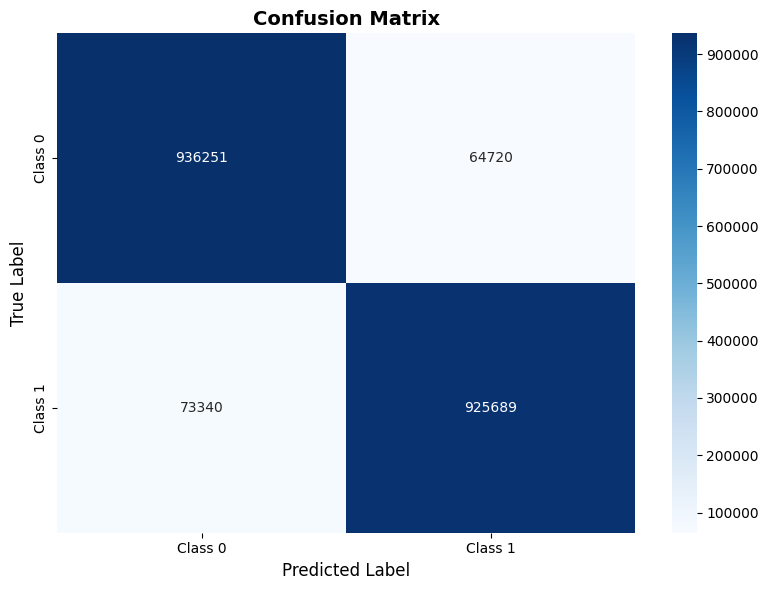


📈 Detailed Metrics:
True Negatives:  936251
False Positives: 64720
False Negatives: 73340
True Positives:  925689

🎯 Performance Metrics:
Accuracy:  0.931
Precision: 0.935
Recall:    0.927


In [17]:
# Demonstration: Confusion Matrix
print("📊 CONFUSION MATRIX EXAMPLE")
print("=" * 40)

# Create and visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate metrics manually
tn, fp, fn, tp = cm.ravel()
print(f"\n📈 Detailed Metrics:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")  
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\n🎯 Performance Metrics:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")

# 🛠️ PART 2: What is Data Preprocessing?

## Why Preprocessing Matters

Raw data is rarely ready for machine learning algorithms. Data preprocessing is crucial because:

### 🚫 **Common Data Problems:**
- **Missing values**: Gaps in data that need to be filled
- **Different scales**: Features with vastly different ranges (e.g., age vs income)
- **Categorical data**: Text labels that need numeric encoding
- **Outliers**: Extreme values that can skew results
- **Irrelevant features**: Noise that hurts model performance

### ✅ **Benefits of Preprocessing:**
- **Improved accuracy**: Clean data leads to better predictions
- **Faster training**: Optimized data trains models quicker
- **Algorithm compatibility**: Makes data suitable for ML algorithms
- **Better convergence**: Helps optimization algorithms work properly

### 🎯 **The Golden Rule:**
> **"Garbage in, garbage out"** - Quality preprocessing is essential for quality results!

## Key Preprocessing Techniques

### 1. 📏 **MinMaxScaler**
- **Purpose**: Scale features to a fixed range (usually 0-1)
- **Formula**: (value - min) / (max - min)
- **When to use**: When features have different scales
- **Pros**: Preserves relationships, bounded output
- **Cons**: Sensitive to outliers

### 2. 🏷️ **OneHotEncoder**  
- **Purpose**: Convert categorical variables to binary columns
- **Example**: ['Red', 'Blue', 'Green'] → [1,0,0], [0,1,0], [0,0,1]
- **When to use**: Nominal categories (no order)
- **Pros**: No artificial ordering imposed
- **Cons**: Can create many columns (curse of dimensionality)

### 3. 🔢 **LabelEncoder**
- **Purpose**: Convert categorical variables to integers
- **Example**: ['Small', 'Medium', 'Large'] → [0, 1, 2]
- **When to use**: Ordinal categories (natural order)
- **Pros**: Compact representation
- **Cons**: May imply false ordering for nominal data

In [ ]:
# Demonstration: Preprocessing Techniques
print("🛠️ PREPROCESSING DEMONSTRATIONS")
print("=" * 50)

# Create sample data with different types
np.random.seed(42)
sample_data = pd.DataFrame({
    'age': np.random.randint(18, 80, 100),
    'income': np.random.normal(50000, 20000, 100),
    'education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], 100),
    'city': np.random.choice(['New York', 'London', 'Tokyo', 'Sydney'], 100)
})

print("📊 Original Sample Data:")
print(sample_data.head())
print(f"\nData types:\n{sample_data.dtypes}")
print(f"\nData shape: {sample_data.shape}")

# 1. MinMaxScaler Example
print("\n" + "="*30)
print("📏 MINMAXSCALER EXAMPLE")
print("="*30)



In [ ]:
# 2. OneHotEncoder Example
print("\n" + "="*30)
print("🏷️ ONEHOTENCODER EXAMPLE")
print("="*30)



# 3. LabelEncoder Example  
print("\n" + "="*30)
print("🔢 LABELENCODER EXAMPLE")
print("="*30)



## Scikit-Learn Pipelines & Avoiding Data Leakage

### 🔧 **What are Pipelines?**
Pipelines are a way to chain preprocessing steps and models together, ensuring:
- **Reproducibility**: Same steps applied consistently
- **Code cleanliness**: Organized and readable workflow
- **Parameter tuning**: Easy to optimize entire pipeline
- **Deployment**: Simple to put into production

### ⚠️ **Data Leakage Prevention**
**Data leakage** occurs when information from the future or test set "leaks" into training:

#### **Common Leakage Sources:**
1. **Preprocessing before splitting**: Scaling using entire dataset statistics
2. **Target leakage**: Features that wouldn't be available at prediction time
3. **Temporal leakage**: Using future information to predict the past

#### **Prevention Strategy:**
- **✅ Fit preprocessing on training data only**
- **✅ Transform both training and test data with training statistics**
- **❌ Never fit preprocessing on test data**

In [12]:
np.random.seed(67)
total_data = 1000
x_sample = pd.DataFrame({
    'age':np.random.randint(18, 80, total_data),
    'income':np.random.normal(50000, 20000, total_data),
    'education':np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], total_data),
    'city':np.random.choice(['New York', 'London', 'Tokyo', 'Paris'], total_data)
})
y_sample = np.random.choice([0,1], size=total_data)

x_train, x_test, y_train, y_test = train_test_split(x_sample, y_sample, test_size = 0.2, random_state=67)
print(f"Data split: {len(x_train)} training, {len(x_test)} testing samples")

numeric_features = ['age', 'income']
categorical_features = ['education', 'city']

numeric_transformer = MinMaxScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
) 

#Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=67))
])

pipeline.fit(X=x_train, y=y_train)
print("Pipeline fitted on training data only")

y_pred = pipeline.predict(x_test)
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)

print(f"Pipeline accuracy:{accuracy}")




Data split: 800 training, 200 testing samples
Pipeline fitted on training data only
Pipeline accuracy:0.455
